<a href="https://colab.research.google.com/github/vitthalsahai5-ui/delhi-weather-predictor/blob/main/weather_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
date,meantemp,humidity,wind_speed,meanpressure
2013-01-01,10.0,84.5,0.0,1015.6666666666666
2013-01-02,7.4,92.0,2.98,1017.8
2013-01-03,7.166666666666667,87.0,4.633333333333334,1018.6666666666666
2013-01-04,8.666666666666666,71.33333333333333,1.2333333333333334,1017.1666666666666
2013-01-05,6.0,86.83333333333333,3.6999999999999997,1016.5
2013-01-06,7.0,82.8,1.48,1018.0
2013-01-07,7.0,78.6,6.3,1020.0
2013-01-08,8.857142857142858,63.714285714285715,7.142857142857143,1018.7142857142857
2013-01-09,14.0,51.25,12.5,1017.0
2013-01-10,11.0,62.0,7.3999999999999995,1015.6666666666666
2013-01-11,15.714285714285714,51.285714285714285,10.571428571428571,1016.1428571428571
2013-01-12,14.0,74.0,13.228571428571428,1015.5714285714286
2013-01-13,15.833333333333334,75.16666666666667,4.633333333333334,1013.3333333333334
2013-01-14,12.833333333333334,88.16666666666667,0.61666666666

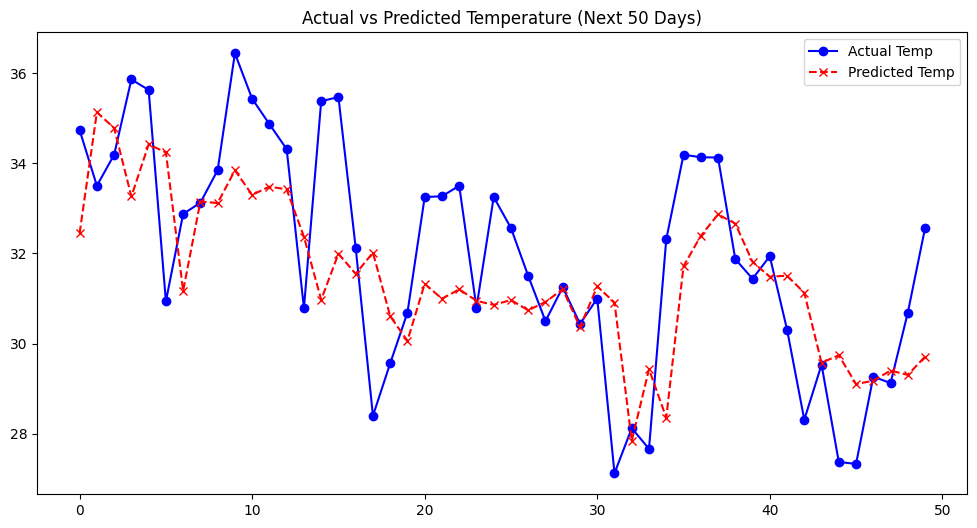

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/delhi weather/your_weather_data.csv'
with open(file_path, 'r') as file:
    content=file.read()
    print(content)


# 1. Load the Data
df = pd.read_csv(file_path)

# 2. Preprocessing (Adapting to typical Kaggle formats)
# Convert date to datetime and extract features
df['date'] = pd.to_datetime(df['date']) # Changed 'date_column_name' to 'date'
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month

# Handling missing values (Forward fill is best for time-series)
df = df.ffill()

# 3. Feature Selection
# Let's say we want to predict 'meantemp' (Mean Temperature)
# We use features from 'today' to predict 'tomorrow'
df['target_temp'] = df['meantemp'].shift(-1)
df = df.dropna() # Drop the last row because it won't have a 'tomorrow' value

features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'day_of_year', 'month']
X = df[features]
y = df['target_temp']

# 4. Split Data (Keep the order for time-series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Predictions & Evaluation
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Model Mean Absolute Error: {mae:.2f}°C")
print(f"Model Accuracy (R2 Score): {r2_score(y_test, predictions):.2f}")

# 7. Visualize Results
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Temp', color='blue', marker='o')
plt.plot(predictions[:50], label='Predicted Temp', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted Temperature (Next 50 Days)')
plt.legend()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


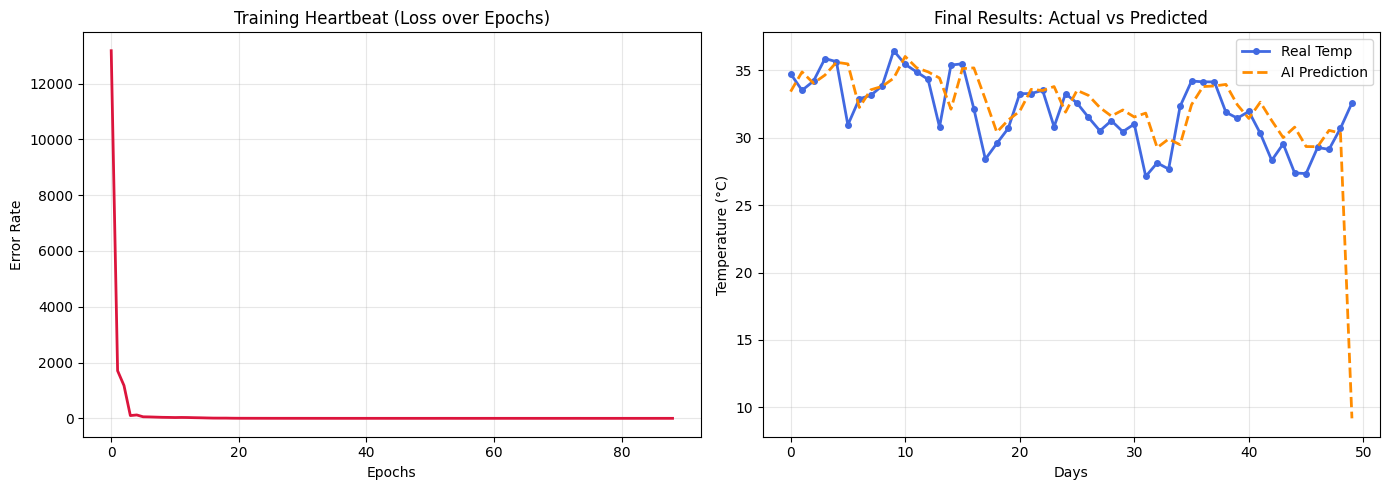

Final Prediction Error: 1.64°C


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

drive.mount('/content/drive')

file_path = '/content/drive/My Drive/delhi weather/your_weather_data.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month
df = df.ffill()

df['target_temp'] = df['meantemp'].shift(-1)
df = df.dropna()

features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'day_of_year', 'month']
X = df[features]
y = df['target_temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define and Train the Neural Network
model = MLPRegressor(hidden_layer_sizes=(100, 50),
                     max_iter=200,
                     random_state=42,
                     verbose=False,
                     learning_rate_init=0.01)

model.fit(X_train, y_train)

# --- GRAPH 1: Learning Progress (Loss over Epochs) ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(model.loss_curve_, color='crimson', linewidth=2)
plt.title('Training Heartbeat (Loss over Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Error Rate')
plt.grid(True, alpha=0.3)

# --- GRAPH 2: Actual vs Predicted Temperature ---
predictions = model.predict(X_test)

plt.subplot(1, 2, 2)
plt.plot(y_test.values[:50], label='Real Temp', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:50], label='AI Prediction', color='darkorange', linestyle='--', linewidth=2)
plt.title('Final Results: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Prediction Error: {mean_absolute_error(y_test, predictions):.2f}°C")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/delhi weather/your_weather_data.csv'
with open(file_path, 'r') as file:
    content=file.read()
    print(content)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
date,meantemp,humidity,wind_speed,meanpressure
2013-01-01,10.0,84.5,0.0,1015.6666666666666
2013-01-02,7.4,92.0,2.98,1017.8
2013-01-03,7.166666666666667,87.0,4.633333333333334,1018.6666666666666
2013-01-04,8.666666666666666,71.33333333333333,1.2333333333333334,1017.1666666666666
2013-01-05,6.0,86.83333333333333,3.6999999999999997,1016.5
2013-01-06,7.0,82.8,1.48,1018.0
2013-01-07,7.0,78.6,6.3,1020.0
2013-01-08,8.857142857142858,63.714285714285715,7.142857142857143,1018.7142857142857
2013-01-09,14.0,51.25,12.5,1017.0
2013-01-10,11.0,62.0,7.3999999999999995,1015.6666666666666
2013-01-11,15.714285714285714,51.285714285714285,10.571428571428571,1016.1428571428571
2013-01-12,14.0,74.0,13.228571428571428,1015.5714285714286
2013-01-13,15.833333333333334,75.16666666666667,4.633333333333334,1013.3333333333334
2013-01-14,12.833333333333334,88.16666666666667,0.61666666666